<a href="https://colab.research.google.com/github/uditmodi2322-bot/delivery-time-prediction-ml/blob/main/dekivery_google.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os
import glob

# 1. Download
path = kagglehub.dataset_download("jayjoshi37/daily-food-delivery-orders-and-delivery-time")

# 2. Automatically find the CSV file (The Fix)
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset!")

# Load the first CSV found
df = pd.read_csv(csv_files[0])
print(f"Successfully loaded: {os.path.basename(csv_files[0])}")
print("Columns available:", df.columns.tolist())

100%|██████████| 44.8k/44.8k [00:00<00:00, 4.89MB/s]

Extracting files...
Successfully loaded: daily_food_delivery_orders.csv
Columns available: ['order_id', 'order_date', 'customer_age', 'restaurant_type', 'order_value', 'delivery_distance_km', 'delivery_time_minutes', 'payment_method', 'delivery_partner_rating', 'order_status']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


LINEAR REGRESSION ACCURACY: -1.17%
AVERAGE ERROR: 18.12 Minutes


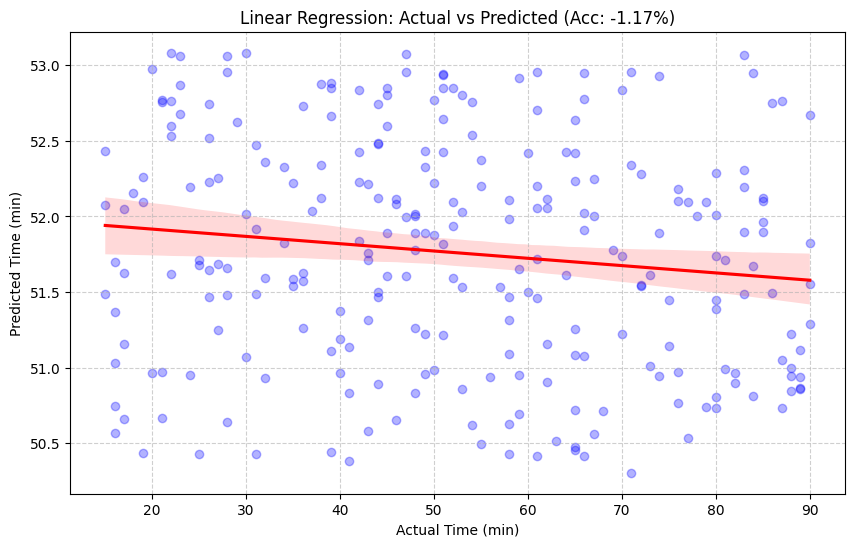

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download and Find File
path = kagglehub.dataset_download("jayjoshi37/daily-food-delivery-orders-and-delivery-time")
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
df = pd.read_csv(csv_files[0])

# 2. Smart Column Finder
def find_col(keywords, columns):
    for k in keywords:
        for c in columns:
            if k.lower() in c.lower():
                return c
    return None

target_col = find_col(['Time_taken', 'Time', 'Duration'], df.columns)
age_col = find_col(['Age'], df.columns)
rating_col = find_col(['Rating'], df.columns)

# 3. Cleaning & Conversion
df = df.dropna()
# Using r'(\d+)' to ensure no SyntaxWarnings
df[target_col] = df[target_col].astype(str).str.extract(r'(\d+)').astype(float)
df[age_col] = df[age_col].astype(str).str.extract(r'(\d+)').astype(float)
df[rating_col] = pd.to_numeric(df[rating_col], errors='coerce')

# 4. Prepare Features (X) and Target (y)
X = df[[age_col, rating_col]].dropna()
y = df.loc[X.index, target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# 5. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Accuracy Metrics
y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred) * 100
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*40)
print(f"LINEAR REGRESSION ACCURACY: {accuracy:.2f}%")
print(f"AVERAGE ERROR: {mae:.2f} Minutes")
print("="*40)

# 7. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
plt.title(f'Linear Regression: Actual vs Predicted (Acc: {accuracy:.2f}%)')
plt.xlabel('Actual Time (min)')
plt.ylabel('Predicted Time (min)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()